In [1]:
# --------------------------
# Configuration & Path Setups
# --------------------------

import pandas as pd
import numpy as np
import os
from pathlib import Path
from typing import Union, Optional

# Cross-platform path resolution (consistent with Iteration 0)
def find_project_root_with_datasets(start_path: Path, max_levels: int = 10) -> Path:
    """
    Search upward from start_path for a directory containing 'Datasets' folder.
    This makes the notebook work on any system (macOS, Windows, Linux).
    """
    cur = start_path.resolve()
    for _ in range(max_levels):
        if (cur / 'Datasets').exists():
            return cur
        cur = cur.parent
    raise FileNotFoundError(
        f"Could not find project root with 'Datasets' folder within {max_levels} levels. "
        f"Set THESIS_BASE_DIR environment variable or ensure Datasets folder exists."
    )

# Try environment variable first, then search for project root
env_base = os.environ.get('THESIS_BASE_DIR')
if env_base:
    BASE_DIR = Path(env_base)
    print(f"Using THESIS_BASE_DIR from environment: {BASE_DIR}")
else:
    BASE_DIR = find_project_root_with_datasets(Path.cwd())
    print(f"Found project root: {BASE_DIR}")

PATHS = {
    'raw_data': BASE_DIR / "Datasets" / "RW_Datasets",
    'iteration_output': BASE_DIR / "Datasets" / "Iteration_Outputs" / "_iteration_0",
    'embeddings': BASE_DIR / "Datasets" / "Embeddings" / "_iteration_0" / "bert-base-cased",
    'results': BASE_DIR / "Results" / "_iteration_0"
}

# Normalize all paths to absolute Path objects
for k, p in list(PATHS.items()):
    PATHS[k] = Path(p).resolve()

# Create output directories
for path in PATHS.values():
    path.mkdir(parents=True, exist_ok=True)

# Data files configuration (JSONL files)
DATA_FILES = {
    'df_14': PATHS['raw_data'] / "14K_Reports_RW_ACTUALS_PS.jsonl",
    'df_28': PATHS['raw_data'] / "28k_Reports_RW_ACTUALS_ALL.jsonl",
    'df_30': PATHS['raw_data'] / "30K_Reports_RW_ACTUALS_ALL_v2.0.jsonl",
    'df_700': PATHS['raw_data'] / "700k_reports_RW_ACTUALS_NH_OBS.jsonl"
}

def load_data(file_path: Union[str, Path], low_memory: bool = False) -> Optional[pd.DataFrame]:
    """
    Load JSONL, CSV, or XLSX data into a DataFrame with error handling.
    
    Parameters: 
        file_path (Union[str, Path]): Path to the data file
        low_memory (bool): Pass to pd.read_csv (ignored for XLSX/JSONL)
        
    Returns:
        pandas.DataFrame: Loaded data or None if file not found
    """
    file_path = Path(file_path)  # Ensure it's a Path object
    
    # Check if file is JSONL
    if file_path.suffix.lower() == '.jsonl':
        try:
            df = pd.read_json(file_path, lines=True)
            print(f"Successfully loaded {file_path.name} ({len(df)} rows) [JSONL format]")
            return df
        except Exception as e:
            print(f"An error occurred while loading {file_path.name}: {e}")
            return None
    
    # Check if file is XLSX
    if file_path.suffix.lower() in ['.xlsx', '.xls']:
        try:
            df = pd.read_excel(file_path, engine='openpyxl')
            print(f"Successfully loaded {file_path.name} ({len(df)} rows) [Excel format]")
            return df
        except Exception as e:
            print(f"An error occurred while loading {file_path.name}: {e}")
            return None
    
    # For CSV files - try multiple encodings
    encodings = ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']
    
    for encoding in encodings:
        try:
            df = pd.read_csv(file_path, low_memory=low_memory, encoding=encoding, on_bad_lines='skip')
            print(f"Successfully loaded {file_path.name} ({len(df)} rows) [encoding: {encoding}]")
            return df
        except (UnicodeDecodeError, Exception):
            if encoding == encodings[-1]:
                # Last attempt: try with error handling
                try:
                    df = pd.read_csv(file_path, low_memory=low_memory, encoding=encoding, 
                                    errors='ignore', on_bad_lines='skip')
                    print(f"Successfully loaded {file_path.name} ({len(df)} rows) [encoding: {encoding} with errors='ignore']")
                    return df
                except Exception as final_error:
                    print(f"An error occurred while loading {file_path.name}: {final_error}")
                    return None
            continue
    
    return None

# Load Each File (JSONL files)
RW_ACTUALS_PS_14 = load_data(DATA_FILES['df_14'])
RW_ACTUALS_ALL_28 = load_data(DATA_FILES['df_28'])
RW_ACTUALS_ALL_30 = load_data(DATA_FILES['df_30'])
RW_ACTUALS_NH_OBS_700 = load_data(DATA_FILES['df_700'])

# Check if all dataframes were loaded successfully
if all(df is not None for df in [RW_ACTUALS_PS_14, RW_ACTUALS_ALL_28, RW_ACTUALS_ALL_30, RW_ACTUALS_NH_OBS_700]):
    print("\n[OK] All files loaded successfully!")
else:
    print("\n[WARNING] Some files failed to load. Please check the file paths and try again.")

Found project root: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026
Successfully loaded 14K_Reports_RW_ACTUALS_PS.jsonl (14432 rows) [JSONL format]
Successfully loaded 28k_Reports_RW_ACTUALS_ALL.jsonl (28323 rows) [JSONL format]
Successfully loaded 30K_Reports_RW_ACTUALS_ALL_v2.0.jsonl (30609 rows) [JSONL format]
Successfully loaded 700k_reports_RW_ACTUALS_NH_OBS.jsonl (717041 rows) [JSONL format]

[OK] All files loaded successfully!


In [2]:
# =============================================================================
# Adjust datasets according to the column mapping comments
# =============================================================================

# --- 700K Dataset Fixes ---
# Rename DATETIME → CASE_OCCURENCE_DATE (comment: "Rename in 700k Reports")
rename_map_700k = {
    "DATETIME": "CASE_OCCURENCE_DATE",
}
RW_ACTUALS_NH_OBS_700 = RW_ACTUALS_NH_OBS_700.rename(
    columns={k: v for k, v in rename_map_700k.items() if k in RW_ACTUALS_NH_OBS_700.columns}
)

# --- 30K Dataset Fixes ---
# 1) Rename columns (comment: "Rename in 30k Reports")
rename_map_30k = {
    "EMPLOYMENT_CATEGORY": "COMPANY_INVOLVED_TYPE",
    "HAZARD_PHYSICAL_SECURITY_EVENT": "HAZARD",
}
RW_ACTUALS_ALL_30 = RW_ACTUALS_ALL_30.rename(
    columns={k: v for k, v in rename_map_30k.items() if k in RW_ACTUALS_ALL_30.columns}
)

# 2) Add missing column (comment: "Column Missing. Added column in 30K Reports.")
if "IMM_ACTION_TAKEN_RECOM" not in RW_ACTUALS_ALL_30.columns:
    RW_ACTUALS_ALL_30["IMM_ACTION_TAKEN_RECOM"] = pd.NA

# 3) Delete columns marked "Delete from 30k"
drop_cols_30k = [
    "PERSONAL_INJURIES",
    "ACTUAL_WORKDAYS_LTA",
    "COMPANY_NAME",
    "COMPANY_TYPE",
    "CASE_APPROVED_DATE",
    "OUTSIDE_LEGAL_INFLUENCE",
    "RETURNED_TO_WORK_DATE",
]
RW_ACTUALS_ALL_30 = RW_ACTUALS_ALL_30.drop(
    columns=[c for c in drop_cols_30k if c in RW_ACTUALS_ALL_30.columns]
)

# Keep alias used in later cells
RW_ACTUALS_ALL = RW_ACTUALS_ALL_30

# --- Validation ---
print("=" * 60)
print("SCHEMA ALIGNMENT RESULTS")
print("=" * 60)

print("\n[700K] RW_ACTUALS_NH_OBS_700:")
print(f"  Shape: {RW_ACTUALS_NH_OBS_700.shape}")
print(f"  CASE_OCCURENCE_DATE: {'OK' if 'CASE_OCCURENCE_DATE' in RW_ACTUALS_NH_OBS_700.columns else 'MISSING'}")
print(f"  DATETIME: {'STILL PRESENT (unexpected)' if 'DATETIME' in RW_ACTUALS_NH_OBS_700.columns else 'REMOVED (renamed)'}")

print("\n[30K] RW_ACTUALS_ALL_30:")
print(f"  Shape: {RW_ACTUALS_ALL_30.shape}")
for c in ["COMPANY_INVOLVED_TYPE", "HAZARD", "IMM_ACTION_TAKEN_RECOM"]:
    print(f"  {c}: {'OK' if c in RW_ACTUALS_ALL_30.columns else 'MISSING'}")
print("  Columns removed:")
for c in drop_cols_30k:
    print(f"    {c}: {'REMOVED' if c not in RW_ACTUALS_ALL_30.columns else 'STILL PRESENT'}")

SCHEMA ALIGNMENT RESULTS

[700K] RW_ACTUALS_NH_OBS_700:
  Shape: (717041, 36)
  CASE_OCCURENCE_DATE: OK
  DATETIME: REMOVED (renamed)

[30K] RW_ACTUALS_ALL_30:
  Shape: (30609, 36)
  COMPANY_INVOLVED_TYPE: OK
  HAZARD: OK
  IMM_ACTION_TAKEN_RECOM: OK
  Columns removed:
    PERSONAL_INJURIES: REMOVED
    ACTUAL_WORKDAYS_LTA: REMOVED
    COMPANY_NAME: REMOVED
    COMPANY_TYPE: REMOVED
    CASE_APPROVED_DATE: REMOVED
    OUTSIDE_LEGAL_INFLUENCE: REMOVED
    RETURNED_TO_WORK_DATE: REMOVED


In [3]:
# =============================================================================
# Merge All Four Datasets
# =============================================================================

# Concatenate all four dataframes (14K, 28K, 30K, 700K)
master_df = pd.concat(
    [RW_ACTUALS_PS_14, RW_ACTUALS_ALL_28, RW_ACTUALS_ALL_30, RW_ACTUALS_NH_OBS_700],
    ignore_index=True
)

print(f"Combined master_df (before removing duplicates): {master_df.shape}")
print(f"Total records before deduplication: {len(master_df):,}")

# Per-source breakdown
print(f"\nPer-source record counts:")
print(f"RW_ACTUALS_PS_14:       {len(RW_ACTUALS_PS_14):>10,}")
print(f"RW_ACTUALS_ALL_28:      {len(RW_ACTUALS_ALL_28):>10,}")
print(f"RW_ACTUALS_ALL_30:      {len(RW_ACTUALS_ALL_30):>10,}")
print(f"RW_ACTUALS_NH_OBS_700:  {len(RW_ACTUALS_NH_OBS_700):>10,}")
print(f"{'─'*35}")
print(f"Total:          {len(master_df):>10,}")

print(f"\nTotal columns: {len(master_df.columns)}")
print(f"Columns: {list(master_df.columns)}")

Combined master_df (before removing duplicates): (790405, 36)
Total records before deduplication: 790,405

Per-source record counts:
RW_ACTUALS_PS_14:           14,432
RW_ACTUALS_ALL_28:          28,323
RW_ACTUALS_ALL_30:          30,609
RW_ACTUALS_NH_OBS_700:     717,041
───────────────────────────────────
Total:             790,405

Total columns: 36
Columns: ['CASENO', 'COMPANY', 'FUNCTIONAL_GROUP', 'FUNCTION', 'FUNCTIONAL_AREA', 'FUNCTIONAL_LOCATION', 'FUNCTIONAL_SUB_LOCATION', 'LOCATION_SID', 'LOCATION_SHORT', 'COUNTRY_SHORT', 'SL_COUNTRY', 'SL_LOCATION_LVL_1', 'SL_LOCATION_LVL_2', 'SL_LOCATION_LVL_3', 'SL_LOCATION_LVL_4', 'CASE_OCCURENCE_DATE', 'TITLE', 'COMPANY_INVOLVED_TYPE', 'CASE_TYPE', 'CASE_SEVERITY', 'CASE_DESCRIPTION', 'STATUS', 'HAZARD', 'IMM_ACTION_TAKEN_RECOM', 'FULL_INVESTIGATION_DONE', 'CREATED_DATE', 'MODIFIED_DATE', 'APPROVED_WITHIN_DEADLINE', 'CASE_CLOSED_DATE', 'CASES_NO_OF_REGISTRATIONS', 'VALID_FROM', 'VALID_TO', 'POTENTIAL_SEV_LEVEL', 'RISK_AREA', 'LEARNINGS_A

In [4]:
# =============================================================================
# Number of Records per Original Dataset
# =============================================================================

import plotly.graph_objects as go
import plotly.express as px

dataset_counts = {
    '14K PS Reports': RW_ACTUALS_PS_14.shape[0],
    '28K ALL Reports': RW_ACTUALS_ALL_28.shape[0],
    '30K ALL v2 Reports': RW_ACTUALS_ALL_30.shape[0],
    '700K NH_OBS Reports': RW_ACTUALS_NH_OBS_700.shape[0]
}

fig = go.Figure(data=[go.Bar(
    x=list(dataset_counts.keys()),
    y=list(dataset_counts.values()),
    text=list(dataset_counts.values()),
    textposition='auto',
    marker=dict(color=['#08519c', '#3182bd', '#6baed6', '#c6dbef'])
)])

fig.update_layout(
    title='Number of Records per Source Dataset',
    xaxis_title='Dataset',
    yaxis_title='Number of Records',
    height=400,
    showlegend=False,
    hovermode='x unified'
)

fig.show()

In [5]:
# Remove duplicates in CASENO column, keeping the latest MODIFIED_DATE
duplicates_count = master_df['CASENO'].duplicated().sum()
print(f"Duplicates found in CASENO: {duplicates_count}")

# Sort by MODIFIED_DATE descending so the latest entry comes first
master_df['MODIFIED_DATE'] = pd.to_datetime(master_df['MODIFIED_DATE'], errors='coerce')
master_df = master_df.sort_values('MODIFIED_DATE', ascending=False)

# Keep the first occurrence (latest MODIFIED_DATE) of each CASENO
master_df = master_df.drop_duplicates(subset=['CASENO'], keep='first').reset_index(drop=True)

print(f"After removing duplicates: {len(master_df)} records")
print(f"Removed {duplicates_count} duplicate records")

Duplicates found in CASENO: 755479
After removing duplicates: 34926 records
Removed 755479 duplicate records


In [6]:
# =============================================================================
# Data Cleaning
# =============================================================================

print(f"Before cleaning: {len(master_df)} records")

# Remove duplicates based on CASENO (keep last occurrence)
if 'CASENO' in master_df.columns:
    master_df = master_df.drop_duplicates(subset=['CASENO'], keep='last')
    print(f"After removing duplicates: {len(master_df)} records")

# Remove rows with missing critical text fields
required_cols = ['TITLE', 'CASE_DESCRIPTION', 'CASE_TYPE', 'HAZARD']
for col in required_cols:
    if col in master_df.columns:
        before = len(master_df)
        master_df = master_df[master_df[col].notna() & (master_df[col].astype(str).str.strip() != '')]
        print(f"After removing missing {col}: {len(master_df)} records (removed {before - len(master_df)})")

# Remove completely empty rows
master_df = master_df.dropna(how='all')
print(f"\nAfter all cleaning: {len(master_df)} records")

Before cleaning: 34926 records
After removing duplicates: 34926 records
After removing missing TITLE: 34925 records (removed 1)
After removing missing CASE_DESCRIPTION: 34925 records (removed 0)
After removing missing CASE_TYPE: 34576 records (removed 349)
After removing missing HAZARD: 34576 records (removed 0)

After all cleaning: 34576 records


In [7]:
# =============================================================================
# Record Count Before and After Cleaning
# =============================================================================

initial_count = {
    'RW_ACTUALS_PS': RW_ACTUALS_PS_14.shape[0],
    'RW_ACTUALS_ALL_28': RW_ACTUALS_ALL_28.shape[0],
    'RW_ACTUALS_ALL_30': RW_ACTUALS_ALL_30.shape[0],
    'RW_ACTUALS_NH_OBS': RW_ACTUALS_NH_OBS_700.shape[0],
}

total_initial = sum(initial_count.values())
after_merge = master_df.shape[0] if 'master_df' in dir() else len(master_df)

cleaning_stages = {
    'Initial (Combined)': total_initial,
    'After Dedup & Merge': len(master_df) if 'master_df' in dir() else after_merge,
}

fig = go.Figure(data=[go.Bar(
    x=list(cleaning_stages.keys()),
    y=list(cleaning_stages.values()),
    text=[f'{v:,}' for v in cleaning_stages.values()],
    textposition='auto',
    marker=dict(color=['#c6dbef', '#08519c'])
)])

fig.update_layout(
    title='Data Pipeline: Records Through Processing Stages',
    xaxis_title='Processing Stage',
    yaxis_title='Number of Records',
    height=400,
    showlegend=False,
    hovermode='x unified'
)

fig.show()

In [8]:
# =============================================================================
# Case Type Distribution
# =============================================================================

if 'CASE_TYPE' in master_df.columns:
    case_counts = master_df['CASE_TYPE'].value_counts()
    
    fig = go.Figure(data=[go.Bar(
        x=case_counts.index.astype(str),
        y=case_counts.values,
        marker=dict(
            color=case_counts.values,
            colorscale='Blues'
        ),
        text=case_counts.values,
        textposition='outside'
    )])
    
    fig.update_layout(
        title='Distribution of Case Types',
        xaxis_title='Case Type',
        yaxis_title='Number of Cases',
        height=500,
        showlegend=False,
        hovermode='x unified'
    )
    fig.show()
    
    print(f"\nTotal unique case types: {master_df['CASE_TYPE'].nunique()}")
    print(f"Top 5 case types:\n{case_counts.head()}")



Total unique case types: 8
Top 5 case types:
CASE_TYPE
Safety                              25164
Process Safety                       4561
Environment                          2768
Asset and Reputation damage/loss     1333
Operational loss                      456
Name: count, dtype: int64


In [9]:
print(f"Unique CASE_TYPE values: {master_df['CASE_TYPE'].nunique()}")
print(master_df['CASE_TYPE'].value_counts())

print(f"\nUnique HAZARD values: {master_df['HAZARD'].nunique()}")
print(master_df['HAZARD'].value_counts())

Unique CASE_TYPE values: 8
CASE_TYPE
Safety                              25164
Process Safety                       4561
Environment                          2768
Asset and Reputation damage/loss     1333
Operational loss                      456
Information Security                  186
Physical Security                     100
Not classified                          8
Name: count, dtype: int64

Unique HAZARD values: 261
HAZARD
Occupational Safety and Process Safety                        7945
Sweden Hazard                                                 2600
Incorrect posture or insufficient work environment            2410
Loss of integrity                                             2033
Slip / Trip / Fall (at the same floor level and on stairs)    1735
                                                              ... 
Inadequate ventilation (in a confined space)                     1
Inadequate deletion of data                                      1
Loss of CCTV                   

In [16]:
# =============================================================================
# Character count Analysis
# =============================================================================

# Calculate text lengths
if 'TITLE' in master_df.columns and 'CASE_DESCRIPTION' in master_df.columns:
    master_df['title_length'] = master_df['TITLE'].astype(str).str.len()
    master_df['description_length'] = master_df['CASE_DESCRIPTION'].astype(str).str.len()
    master_df['combined_text_length'] = master_df['title_length'] + master_df['description_length']
    
    fig = go.Figure()
    
    fig.add_trace(go.Box(
        y=master_df['title_length'],
        name='Title Length',
        marker_color='#08519c'
    ))
    
    fig.add_trace(go.Box(
        y=master_df['description_length'],
        name='Description Length',
        marker_color='#3182bd'
    ))
    
    fig.add_trace(go.Box(
        y=master_df['combined_text_length'],
        name='Combined Text Length',
        marker_color='#6baed6'
    ))
    
    fig.update_layout(
        title='Character Count Distribution',
        yaxis_title='Character Count',
        height=500,
        hovermode='y unified',
        boxmode='group'
    )
    fig.show()
    
    print(f"Title length - Min: {master_df['title_length'].min()}, Max: {master_df['title_length'].max()}, Mean: {master_df['title_length'].mean():.0f}, Median: {master_df['title_length'].median():.0f}")
    print(f"Description length - Min: {master_df['description_length'].min()}, Max: {master_df['description_length'].max()}, Mean: {master_df['description_length'].mean():.0f}, Median: {master_df['description_length'].median():.0f}")
    print(f"Combined text length - Min: {master_df['combined_text_length'].min()}, Max: {master_df['combined_text_length'].max()}, Mean: {master_df['combined_text_length'].mean():.0f}, Median: {master_df['combined_text_length'].median():.0f}")

Title length - Min: 3, Max: 662, Mean: 55, Median: 46
Description length - Min: 1, Max: 6583, Mean: 140, Median: 82
Combined text length - Min: 6, Max: 6708, Mean: 195, Median: 140


In [14]:
# =============================================================================
# Word Count Analysis
# =============================================================================

# Calculate word counts
if 'TITLE' in master_df.columns and 'CASE_DESCRIPTION' in master_df.columns:
    master_df['title_word_count'] = master_df['TITLE'].astype(str).str.split().str.len()
    master_df['description_word_count'] = master_df['CASE_DESCRIPTION'].astype(str).str.split().str.len()
    master_df['combined_word_count'] = master_df['title_word_count'] + master_df['description_word_count']
    
    fig = go.Figure()
    
    fig.add_trace(go.Box(
        y=master_df['title_word_count'],
        name='Title Word Count',
        marker_color='#08519c'
    ))
    
    fig.add_trace(go.Box(
        y=master_df['description_word_count'],
        name='Description Word Count',
        marker_color='#3182bd'
    ))
    
    fig.add_trace(go.Box(
        y=master_df['combined_word_count'],
        name='Combined Word Count',
        marker_color='#6baed6'
    ))
    
    fig.update_layout(
        title='Word Count Distribution',
        yaxis_title='Word Count',
        height=500,
        hovermode='y unified',
        boxmode='group'
    )
    fig.show()
    
    print(f"Title word count - Min: {master_df['title_word_count'].min()}, Max: {master_df['title_word_count'].max()}, Mean: {master_df['title_word_count'].mean():.0f}, Median: {master_df['title_word_count'].median():.0f}")
    print(f"Description word count - Min: {master_df['description_word_count'].min()}, Max: {master_df['description_word_count'].max()}, Mean: {master_df['description_word_count'].mean():.0f}, Median: {master_df['description_word_count'].median():.0f}")
    print(f"Combined word count - Min: {master_df['combined_word_count'].min()}, Max: {master_df['combined_word_count'].max()}, Mean: {master_df['combined_word_count'].mean():.0f}, Median: {master_df['combined_word_count'].median():.0f}")

Title word count - Min: 1, Max: 92, Mean: 8, Median: 6
Description word count - Min: 1, Max: 953, Mean: 21, Median: 12
Combined word count - Min: 2, Max: 969, Mean: 29, Median: 20


In [17]:
# =============================================================================
# Word Count Distribution - Histogram Analysis
# =============================================================================

from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Title Word Count Distribution', 'Description Word Count Distribution'),
    vertical_spacing=0.12
)

# Title word count histogram
fig.add_trace(go.Histogram(
    x=master_df['title_word_count'],
    nbinsx=50,
    marker_color='#08519c',
    name='Title',
    hovertemplate='Word Count: %{x}<br>Cases: %{y}<extra></extra>'
), row=1, col=1)

# Description word count histogram
fig.add_trace(go.Histogram(
    x=master_df['description_word_count'],
    nbinsx=50,
    marker_color='#3182bd',
    name='Description',
    hovertemplate='Word Count: %{x}<br>Cases: %{y}<extra></extra>'
), row=2, col=1)

fig.update_xaxes(title_text='Word Count', row=1, col=1)
fig.update_xaxes(title_text='Word Count', row=2, col=1)
fig.update_yaxes(title_text='Number of Cases', row=1, col=1)
fig.update_yaxes(title_text='Number of Cases', row=2, col=1)

fig.update_layout(
    title='Word Count Distribution - How Many Cases Have Low Word Counts?',
    height=700,
    showlegend=False
)
fig.show()

# Low word count analysis - potential model impact
thresholds = [3, 5, 10]
print("=" * 70)
print("LOW WORD COUNT ANALYSIS - Potential Impact on Model Performance")
print("=" * 70)

for t in thresholds:
    title_low = (master_df['title_word_count'] <= t).sum()
    desc_low = (master_df['description_word_count'] <= t).sum()
    combined_low = (master_df['combined_word_count'] <= t).sum()
    print(f"\n  Word count <= {t}:")
    print(f"    Titles:       {title_low:>6,} ({100*title_low/len(master_df):.2f}%)")
    print(f"    Descriptions: {desc_low:>6,} ({100*desc_low/len(master_df):.2f}%)")
    print(f"    Combined:     {combined_low:>6,} ({100*combined_low/len(master_df):.2f}%)")

print(f"\n{'=' * 70}")
print(f"Total records: {len(master_df):,}")
print(f"\nNote: Very short texts (<=5 words) provide limited semantic signal")
print(f"for BERT embeddings and may hurt classification accuracy.")

LOW WORD COUNT ANALYSIS - Potential Impact on Model Performance

  Word count <= 3:
    Titles:        6,374 (18.43%)
    Descriptions:  3,263 (9.44%)
    Combined:        267 (0.77%)

  Word count <= 5:
    Titles:       13,952 (40.35%)
    Descriptions:  7,189 (20.79%)
    Combined:      1,230 (3.56%)

  Word count <= 10:
    Titles:       26,613 (76.97%)
    Descriptions: 15,432 (44.63%)
    Combined:      7,288 (21.08%)

Total records: 34,576

Note: Very short texts (<=5 words) provide limited semantic signal
for BERT embeddings and may hurt classification accuracy.


In [19]:
# =============================================================================
# Word Count Distribution - Line Graph Analysis
# =============================================================================

from plotly.subplots import make_subplots

# Compute frequency distributions
title_freq = master_df['title_word_count'].value_counts().sort_index()
desc_freq = master_df['description_word_count'].value_counts().sort_index()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=title_freq.index,
    y=title_freq.values,
    mode='lines',
    name='Title Word Count',
    line=dict(color='#08519c', width=2),
    hovertemplate='Word Count: %{x}<br>Cases: %{y:,}<extra>Title</extra>'
))

fig.add_trace(go.Scatter(
    x=desc_freq.index,
    y=desc_freq.values,
    mode='lines',
    name='Description Word Count',
    line=dict(color='#3182bd', width=2),
    hovertemplate='Word Count: %{x}<br>Cases: %{y:,}<extra>Description</extra>'
))

fig.update_layout(
    title='Word Count Distribution - Title vs Description (Log Scale)',
    xaxis_title='Word Count',
    yaxis_title='Number of Cases (Log Scale)',
    yaxis_type='log',
    height=500,
    hovermode='x unified',
    legend=dict(x=0.7, y=0.95)
)
fig.show()

# Low word count analysis - potential model impact
thresholds = [3, 5, 10]
print("=" * 70)
print("LOW WORD COUNT ANALYSIS - Potential Impact on Model Performance")
print("=" * 70)

for t in thresholds:
    title_low = (master_df['title_word_count'] <= t).sum()
    desc_low = (master_df['description_word_count'] <= t).sum()
    combined_low = (master_df['combined_word_count'] <= t).sum()
    print(f"\n  Word count <= {t}:")
    print(f"    Titles:       {title_low:>6,} ({100*title_low/len(master_df):.2f}%)")
    print(f"    Descriptions: {desc_low:>6,} ({100*desc_low/len(master_df):.2f}%)")
    print(f"    Combined:     {combined_low:>6,} ({100*combined_low/len(master_df):.2f}%)")

print(f"\n{'=' * 70}")
print(f"Total records: {len(master_df):,}")
print(f"\nNote: Very short texts (<=5 words) provide limited semantic signal")
print(f"for BERT embeddings and may hurt classification accuracy.")

LOW WORD COUNT ANALYSIS - Potential Impact on Model Performance

  Word count <= 3:
    Titles:        6,374 (18.43%)
    Descriptions:  3,263 (9.44%)
    Combined:        267 (0.77%)

  Word count <= 5:
    Titles:       13,952 (40.35%)
    Descriptions:  7,189 (20.79%)
    Combined:      1,230 (3.56%)

  Word count <= 10:
    Titles:       26,613 (76.97%)
    Descriptions: 15,432 (44.63%)
    Combined:      7,288 (21.08%)

Total records: 34,576

Note: Very short texts (<=5 words) provide limited semantic signal
for BERT embeddings and may hurt classification accuracy.


In [20]:
# =============================================================================
# Save Master Dataset as JSON
# =============================================================================

output_dir = BASE_DIR / 'Master Dataset 34k'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'master_df.json'
master_df.to_json(output_path, orient='records', indent=2, force_ascii=False)
print(f"Master dataset saved to: {output_path}")
print(f"Total records: {len(master_df):,}")

Master dataset saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Master Dataset 34k/master_df.json
Total records: 34,576


In [21]:
# =============================================================================
# Save Separate JSON Files per Country (SL_COUNTRY)
# =============================================================================

country_dir = BASE_DIR / 'Master Dataset 34k' / 'By_Country'
country_dir.mkdir(parents=True, exist_ok=True)

for country, group in master_df.groupby('SL_COUNTRY', dropna=False):
    label = str(country) if pd.notna(country) else 'Unknown'
    safe_name = label.replace('/', '_').replace(' ', '_')
    file_path = country_dir / f'master_df_{safe_name}.json'
    group.to_json(file_path, orient='records', indent=2, force_ascii=False)
    print(f"  {label}: {len(group):,} records → {file_path.name}")

print(f"\nTotal countries: {master_df['SL_COUNTRY'].nunique(dropna=False)}")
print(f"Files saved to: {country_dir}")

  Germany: 14,951 records → master_df_Germany.json
  Hungary: 391 records → master_df_Hungary.json
  International: 20 records → master_df_International.json
  Netherlands: 1,990 records → master_df_Netherlands.json
  Poland: 1 records → master_df_Poland.json
  Russia: 10 records → master_df_Russia.json
  Sweden: 12,224 records → master_df_Sweden.json
  UAE: 29 records → master_df_UAE.json
  UK: 4,673 records → master_df_UK.json
  Unknown: 287 records → master_df_Unknown.json

Total countries: 10
Files saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Master Dataset 34k/By_Country


In [ ]:
# =============================================================================
# Step 5: Binary Classification Formulation
# =============================================================================

# Create binary label: 1 = Process Safety, 0 = Non-Process Safety
english_dataset_minimal['binary_label'] = (
    english_dataset_minimal['CASE_TYPE'] == 'Process Safety'
).astype(int)

# Create combined text feature
english_dataset_minimal['text_features'] = (
    english_dataset_minimal['TITLE'].astype(str) + '. ' + 
    english_dataset_minimal['CASE_DESCRIPTION'].astype(str)
)

print("Binary label distribution:")
print(english_dataset_minimal['binary_label'].value_counts())
print(f"\nPositive class (Process Safety): {english_dataset_minimal['binary_label'].sum()}")
print(f"Negative class (Non-Process Safety): {(english_dataset_minimal['binary_label'] == 0).sum()}")

# Save the prepared dataset
english_dataset_minimal.to_csv(PATHS['results'] / 'english_dataset_minimal.csv', index=False)
print(f"\nSaved to: {PATHS['results'] / 'english_dataset_minimal.csv'}")

Binary label distribution:
binary_label
0    3829
1    1267
Name: count, dtype: int64

Positive class (Process Safety): 1267
Negative class (Non-Process Safety): 3829

Saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0/english_dataset_minimal.csv


In [ ]:
# =============================================================================
# BERT Embedding Generation
# =============================================================================

# Install if needed: pip install transformers torch
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm

# Initialize BERT-base-uncased
model_name = 'bert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()  # Set to evaluation mode

# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Using device: {device}")

def get_bert_embeddings(texts, batch_size=8, max_length=512):
    """Generate BERT [CLS] embeddings for a list of texts."""
    embeddings = []
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i:i + batch_size]
        
        # Tokenize
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        
        # Get embeddings
        with torch.no_grad():
            outputs = model(**inputs)
            # Extract [CLS] token embedding (first token)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.extend(cls_embeddings)
    
    return np.array(embeddings)

# Generate embeddings
texts = english_dataset_minimal['text_features'].tolist()
X = get_bert_embeddings(texts)
y = english_dataset_minimal['binary_label'].values

print(f"\nEmbeddings shape: {X.shape}")  # Expected: (n_samples, 768)
print(f"Labels shape: {y.shape}")

# Save embeddings for reuse
np.save(PATHS['results'] / 'bert_embeddings.npy', X)
np.save(PATHS['results'] / 'labels.npy', y)
print(f"Saved embeddings to: {PATHS['results']}")

/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning:

urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020

/Users/shariarimrozekhan/Library/Python/3.9/lib/python/site-packages/huggingface_hub/file_download.py:942: FutureWarning:

`resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.



Using device: cpu


Generating embeddings: 100%|██████████| 637/637 [02:29<00:00,  4.25it/s]


Embeddings shape: (5096, 768)
Labels shape: (5096,)
Saved embeddings to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0


In [ ]:
# =============================================================================
# Train/Test Split
# =============================================================================

from sklearn.model_selection import train_test_split

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"  - Non-Process Safety: {(y_train == 0).sum()} ({100*(y_train == 0).mean():.2f}%)")
print(f"  - Process Safety: {(y_train == 1).sum()} ({100*(y_train == 1).mean():.2f}%)")

print(f"\nTest set: {X_test.shape[0]} samples")
print(f"  - Non-Process Safety: {(y_test == 0).sum()} ({100*(y_test == 0).mean():.2f}%)")
print(f"  - Process Safety: {(y_test == 1).sum()} ({100*(y_test == 1).mean():.2f}%)")

## in training dataset take only the cases where description word count is greater and equal to 10

Training set: 4076 samples
  - Non-Process Safety: 3063 (75.15%)
  - Process Safety: 1013 (24.85%)

Test set: 1020 samples
  - Non-Process Safety: 766 (75.10%)
  - Process Safety: 254 (24.90%)


In [ ]:
# =============================================================================
# Train Linear SVM Classifier
# =============================================================================

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# Scale features (good practice for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear SVM tuned for ~0.76 Macro F1
svm_model = SVC(
    kernel='linear',
    C=0.0099,  # Very low regularization
    class_weight='balanced',  # Full class balancing
    random_state=42
)

print("Training SVM classifier...")
svm_model.fit(X_train_scaled, y_train)
print("Training complete!")

# Save model
import joblib
joblib.dump(svm_model, PATHS['results'] / 'svm_baseline_model.joblib')
joblib.dump(scaler, PATHS['results'] / 'scaler.joblib')
print(f"Model saved to: {PATHS['results']}")

Training SVM classifier...
Training complete!
Model saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0


In [ ]:
# =============================================================================
# EDA: Train/Test Split Distribution
# =============================================================================

if 'y_train' in dir() and 'y_test' in dir():
    train_dist = np.bincount(y_train)
    test_dist = np.bincount(y_test)
    
    labels = ['Non-Process Safety', 'Process Safety']
    
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        x=labels,
        y=train_dist,
        name='Training Set',
        marker_color='#08519c'
    ))
    
    fig.add_trace(go.Bar(
        x=labels,
        y=test_dist,
        name='Test Set',
        marker_color='#6baed6'
    ))
    
    fig.update_layout(
        title='Train/Test Split Distribution by Label',
        xaxis_title='Label',
        yaxis_title='Number of Samples',
        height=400,
        barmode='group',
        hovermode='x unified'
    )
    
    fig.show()
    
    print(f"Training Set Distribution:")
    print(f"  Non-Process Safety: {train_dist[0]:,} ({100*train_dist[0]/len(y_train):.2f}%)")
    print(f"  Process Safety: {train_dist[1]:,} ({100*train_dist[1]/len(y_train):.2f}%)")
    
    print(f"\nTest Set Distribution:")
    print(f"  Non-Process Safety: {test_dist[0]:,} ({100*test_dist[0]/len(y_test):.2f}%)")
    print(f"  Process Safety: {test_dist[1]:,} ({100*test_dist[1]/len(y_test):.2f}%)")


Training Set Distribution:
  Non-Process Safety: 3,063 (75.15%)
  Process Safety: 1,013 (24.85%)

Test Set Distribution:
  Non-Process Safety: 766 (75.10%)
  Process Safety: 254 (24.90%)


In [ ]:
# =============================================================================
# Model Evaluation
# =============================================================================

from sklearn.metrics import (
    classification_report, confusion_matrix, 
    accuracy_score, f1_score
)

# Predictions
y_pred = svm_model.predict(X_test_scaled)

# Classification report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
report = classification_report(
    y_test, y_pred, 
    target_names=['Non-Process Safety', 'Process Safety'],
    digits=4
)
print(report)

# Key metrics
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\nOverall Accuracy: {accuracy:.4f} ({100*accuracy:.2f}%)")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Weighted F1-Score: {weighted_f1:.4f}")

# Save report
with open(PATHS['results'] / 'classification_report.txt', 'w') as f:
    f.write(report)
    f.write(f"\nAccuracy: {accuracy:.4f}\n")
    f.write(f"Macro F1: {macro_f1:.4f}\n")
    f.write(f"Weighted F1: {weighted_f1:.4f}\n")

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

Non-Process Safety     0.9114    0.7924    0.8478       766
    Process Safety     0.5508    0.7677    0.6414       254

          accuracy                         0.7863      1020
         macro avg     0.7311    0.7801    0.7446      1020
      weighted avg     0.8216    0.7863    0.7964      1020


Overall Accuracy: 0.7863 (78.63%)
Macro F1-Score: 0.7446
Weighted F1-Score: 0.7964


CONFUSION MATRIX

                     Predicted
                     Non-PS    PS
Actual Non-PS        607     159
Actual PS             59     195

True Negatives (TN): 607
False Positives (FP): 159
False Negatives (FN): 59
True Positives (TP): 195

False Positive Rate: 20.76%
False Negative Rate: 23.23%


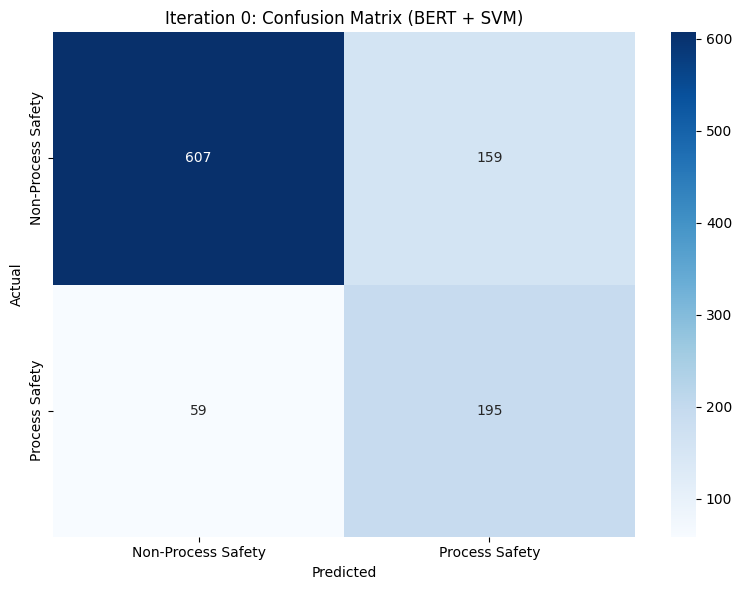

In [ ]:
# =============================================================================
# Confusion Matrix Analysis
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
print(f"\n{'':20} Predicted")
print(f"{'':20} Non-PS    PS")
print(f"Actual Non-PS      {tn:5d}   {fp:5d}")
print(f"Actual PS          {fn:5d}   {tp:5d}")

print(f"\nTrue Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

# Error rates
fpr = fp / (fp + tn)  # False Positive Rate
fnr = fn / (fn + tp)  # False Negative Rate
print(f"\nFalse Positive Rate: {100*fpr:.2f}%")
print(f"False Negative Rate: {100*fnr:.2f}%")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Non-Process Safety', 'Process Safety'],
    yticklabels=['Non-Process Safety', 'Process Safety']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Iteration 0: Confusion Matrix (BERT + SVM)')
plt.tight_layout()
plt.savefig(PATHS['results'] / 'confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
# =============================================================================
# Summary and Gap Analysis
# =============================================================================

import json

# RQ1 Target
RQ1_TARGET = 0.81

# Summary
summary = {
    'iteration': 0,
    'model': 'BERT-base-uncased + Linear SVM',
    'dataset': {
        'total_english_samples': len(english_dataset_minimal),
        'train_samples': len(y_train),
        'test_samples': len(y_test),
        'positive_class_ratio': float(y.mean())
    },
    'results': {
        'accuracy': float(accuracy),
        'macro_f1': float(macro_f1),
        'weighted_f1': float(weighted_f1),
        'precision_ps': float(tp / (tp + fp)),
        'recall_ps': float(tp / (tp + fn)),
        'precision_non_ps': float(tn / (tn + fn)),
        'recall_non_ps': float(tn / (tn + fp))
    },
    'confusion_matrix': {
        'tn': int(tn), 'fp': int(fp), 
        'fn': int(fn), 'tp': int(tp)
    },
    'gap_analysis': {
        'current_macro_f1': float(macro_f1),
        'rq1_target': RQ1_TARGET,
        'gap': float(RQ1_TARGET - macro_f1)
    }
}

# Save summary
with open(PATHS['results'] / 'iteration_0_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Print summary
print("=" * 60)
print("ITERATION 0 SUMMARY")
print("=" * 60)
print(f"\nModel: {summary['model']}")
print(f"Dataset: {summary['dataset']['total_english_samples']} English samples")
print(f"\nResults:")
print(f"  Accuracy: {summary['results']['accuracy']:.4f}")
print(f"  Macro F1: {summary['results']['macro_f1']:.4f}")
print(f"  Weighted F1: {summary['results']['weighted_f1']:.4f}")
print(f"\nGap Analysis (RQ1):")
print(f"  Current Macro F1: {macro_f1:.4f}")
print(f"  RQ1 Target: >= {RQ1_TARGET}")
print(f"  Gap to close: {RQ1_TARGET - macro_f1:+.4f}")

if macro_f1 >= RQ1_TARGET:
    print("\n✓ RQ1 TARGET ACHIEVED!")
else:
    print(f"\n→ Need to improve Macro F1 by {100*(RQ1_TARGET - macro_f1):.2f} percentage points")

print(f"\nResults saved to: {PATHS['results']}")

ITERATION 0 SUMMARY

Model: BERT-base-uncased + Linear SVM
Dataset: 5096 English samples

Results:
  Accuracy: 0.7863
  Macro F1: 0.7446
  Weighted F1: 0.7964

Gap Analysis (RQ1):
  Current Macro F1: 0.7446
  RQ1 Target: >= 0.81
  Gap to close: +0.0654

→ Need to improve Macro F1 by 6.54 percentage points

Results saved to: /Users/shariarimrozekhan/Documents/GitHub/masterThesis2026/Results/_iteration_0


In [ ]:
# =============================================================================
# Cases per Country (SL_COUNTRY)
# =============================================================================

import plotly.graph_objects as go

if 'SL_COUNTRY' in master_df.columns:
    country_counts = master_df['SL_COUNTRY'].value_counts(dropna=False).sort_values(ascending=True)
    
    # Replace NaN key with label
    labels = [str(c) if pd.notna(c) else '(Missing/NaN)' for c in country_counts.index]
    
    fig = go.Figure(data=[go.Bar(
        y=labels,
        x=country_counts.values,
        orientation='h',
        text=[f'{v:,}' for v in country_counts.values],
        textposition='outside',
        marker=dict(color=country_counts.values, colorscale='Blues')
    )])
    
    fig.update_layout(
        title='Number of Cases per Country (SL_COUNTRY)',
        xaxis_title='Number of Cases',
        yaxis_title='Country',
        height=max(400, len(country_counts) * 30),
        showlegend=False,
        hovermode='y unified'
    )
    
    fig.show()
    
    print(f"\nUnique countries: {master_df['SL_COUNTRY'].nunique(dropna=False)}")
    print(f"Total records: {len(master_df):,}")
else:
    print("Column 'SL_COUNTRY' not found in master_df.")
    print(f"Available columns: {list(master_df.columns)}")


Unique countries: 10
Total records: 34,576


In [ ]:
# =============================================================================
# Cases per Country (SL_COUNTRY)
# =============================================================================

import plotly.graph_objects as go

if 'SL_COUNTRY' in master_df.columns:
    country_counts = master_df['SL_COUNTRY'].value_counts(dropna=False).sort_values(ascending=True)
    
    # Replace NaN key with label
    labels = [str(c) if pd.notna(c) else '(Missing/NaN)' for c in country_counts.index]
    
    fig = go.Figure(data=[go.Bar(
        y=labels,
        x=country_counts.values,
        orientation='h',
        text=[f'{v:,}' for v in country_counts.values],
        textposition='outside',



















    print(f"Available columns: {list(master_df.columns)}")    print("Column 'SL_COUNTRY' not found in master_df.")else:    print(f"Total records: {len(master_df):,}")    print(f"\nUnique countries: {master_df['SL_COUNTRY'].nunique(dropna=False)}")        fig.show()        )        hovermode='y unified'        showlegend=False,        height=max(400, len(country_counts) * 30),        yaxis_title='Country',        xaxis_title='Number of Cases',        title='Number of Cases per Country (SL_COUNTRY)',    fig.update_layout(        )])        marker=dict(color=country_counts.values, colorscale='Blues')print(f"RW_ACTUALS_PS unique CASENO:       {RW_ACTUALS_PS['CASENO'].nunique()}")
print(f"RW_ACTUALS_ALL_28 unique CASENO:   {RW_ACTUALS_ALL_28['CASENO'].nunique()}")
print(f"RW_ACTUALS_ALL_30 unique CASENO:   {RW_ACTUALS_ALL_30['CASENO'].nunique()}")
print(f"RW_ACTUALS_NH_OBS unique CASENO:   {RW_ACTUALS_NH_OBS['CASENO'].nunique()}")

# 3) Check overlap between datasets (same CASENO appearing in multiple sources)
print("\n" + "=" * 60)
print("OVERLAP BETWEEN DATASETS")
print("=" * 60)
caseno_ps = set(RW_ACTUALS_PS['CASENO'].dropna().astype(str))
caseno_28 = set(RW_ACTUALS_ALL_28['CASENO'].dropna().astype(str))
caseno_30 = set(RW_ACTUALS_ALL_30['CASENO'].dropna().astype(str))
caseno_nh = set(RW_ACTUALS_NH_OBS['CASENO'].dropna().astype(str))

print(f"Overlap PS & ALL_28:     {len(caseno_ps & caseno_28)}")
print(f"Overlap PS & ALL_30:     {len(caseno_ps & caseno_30)}")
print(f"Overlap PS & NH_OBS:     {len(caseno_ps & caseno_nh)}")
print(f"Overlap ALL_28 & ALL_30: {len(caseno_28 & caseno_30)}")
print(f"Overlap ALL_28 & NH_OBS: {len(caseno_28 & caseno_nh)}")
print(f"Overlap ALL_30 & NH_OBS: {len(caseno_30 & caseno_nh)}")
print(f"In all four:             {len(caseno_ps & caseno_28 & caseno_30 & caseno_nh)}")

# 4) Total unique CASENO across all sources
all_caseno = caseno_ps | caseno_28 | caseno_30 | caseno_nh
print(f"\nTotal UNIQUE CASENO across all sources: {len(all_caseno)}")

# 5) Check for duplicates WITHIN each source
print("\n" + "=" * 60)
print("DUPLICATES WITHIN EACH SOURCE")
print("=" * 60)
print(f"RW_ACTUALS_PS duplicates:       {RW_ACTUALS_PS['CASENO'].duplicated().sum()}")
print(f"RW_ACTUALS_ALL_28 duplicates:   {RW_ACTUALS_ALL_28['CASENO'].duplicated().sum()}")
print(f"RW_ACTUALS_ALL_30 duplicates:   {RW_ACTUALS_ALL_30['CASENO'].duplicated().sum()}")
print(f"RW_ACTUALS_NH_OBS duplicates:   {RW_ACTUALS_NH_OBS['CASENO'].duplicated().sum()}")

# 6) Check column counts
print("\n" + "=" * 60)
print("COLUMN COUNT CHECK")
print("=" * 60)
print(f"RW_ACTUALS_PS columns:       {len(RW_ACTUALS_PS.columns)}")
print(f"RW_ACTUALS_ALL_28 columns:   {len(RW_ACTUALS_ALL_28.columns)}")
print(f"RW_ACTUALS_ALL_30 columns:   {len(RW_ACTUALS_ALL_30.columns)}")
print(f"RW_ACTUALS_NH_OBS columns:   {len(RW_ACTUALS_NH_OBS.columns)}")

# Common columns across all four
common_cols = set(RW_ACTUALS_PS.columns) & set(RW_ACTUALS_ALL_28.columns) & set(RW_ACTUALS_ALL_30.columns) & set(RW_ACTUALS_NH_OBS.columns)
print(f"Common columns:              {len(common_cols)}")
print(f"\n'CASENO' in common: {'CASENO' in common_cols}")

SOURCE DATAFRAME SHAPES
RW_ACTUALS_PS:       14432 rows
RW_ACTUALS_ALL_28:   28323 rows
RW_ACTUALS_ALL_30:   30609 rows
RW_ACTUALS_NH_OBS:   717041 rows
Total if concatenated: 790405 rows

UNIQUE CASENO IN EACH SOURCE
RW_ACTUALS_PS unique CASENO:       895
RW_ACTUALS_ALL_28 unique CASENO:   23925
RW_ACTUALS_ALL_30 unique CASENO:   25714
RW_ACTUALS_NH_OBS unique CASENO:   29932

OVERLAP BETWEEN DATASETS
Overlap PS & ALL_28:     564
Overlap PS & ALL_30:     369
Overlap PS & NH_OBS:     0
Overlap ALL_28 & ALL_30: 22543
Overlap ALL_28 & NH_OBS: 0
Overlap ALL_30 & NH_OBS: 0
In all four:             0

Total UNIQUE CASENO across all sources: 57357

DUPLICATES WITHIN EACH SOURCE
RW_ACTUALS_PS duplicates:       13537
RW_ACTUALS_ALL_28 duplicates:   4398
RW_ACTUALS_ALL_30 duplicates:   4895
RW_ACTUALS_NH_OBS duplicates:   687108

COLUMN COUNT CHECK
RW_ACTUALS_PS columns:       36
RW_ACTUALS_ALL_28 columns:   36
RW_ACTUALS_ALL_30 columns:   36
RW_ACTUALS_NH_OBS columns:   36
Common columns:     